In [32]:
import pandas as pd
df=pd.read_csv("IPL.csv")
print(df.shape) 

C:\Users\meher\AppData\Local\Temp\ipykernel_19204\2584191786.py:2: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("IPL.csv")


(283678, 65)


In [33]:
matches = df.drop_duplicates(subset='match_id')
matches = matches[['match_id', 'date', 'season', 'city', 'venue',
                   'toss_winner', 'toss_decision', 'match_won_by',
                   'win_outcome', 'player_of_match']].reset_index(drop=True)

print(matches.shape)
print(matches.head())

(1193, 10)
   match_id        date   season        city  \
0    335982  2008-04-18  2007/08   Bangalore   
1    335983  2008-04-19  2007/08  Chandigarh   
2    335984  2008-04-19  2007/08       Delhi   
3    335985  2008-04-20  2007/08      Mumbai   
4    335986  2008-04-20  2007/08     Kolkata   

                                        venue                  toss_winner  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali          Chennai Super Kings   
2                            Feroz Shah Kotla             Rajasthan Royals   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens              Deccan Chargers   

  toss_decision                 match_won_by win_outcome player_of_match  
0         field        Kolkata Knight Riders    140 runs     BB McCullum  
1           bat          Chennai Super Kings     33 runs      MEK Hussey  
2     

In [34]:
matches.to_excel("ipl_matches.xlsx", index=False)
print("Done! File saved.")

Done! File saved.


In [35]:
import sqlite3

In [36]:
#load the matches data from the Excel file
matches=pd.read_excel("ipl_matches.xlsx")

#create a database and load the table into it
conn=sqlite3.connect("ipl.db")
matches.to_sql("matches", conn, if_exists="replace", index=False)
print("Database ready!")

Database ready!


In [37]:
#total wins by team
query= """
select match_won_by, count(*) as total_wins
from matches
group by match_won_by
order by total_wins desc
limit 10
"""
pd.read_sql(query, conn)


,match_won_by,total_wins
0,Mumbai Indians,152
1,Chennai Super Kings,144
2,Kolkata Knight Riders,135
3,Rajasthan Royals,118
4,Royal Challengers Bangalore,114
5,Sunrisers Hyderabad,95
6,Kings XI Punjab,85
7,Delhi Daredevils,67
8,Delhi Capitals,53
9,Gujarat Titans,39


In [38]:
#whether winning the toss helps in winning the match
query = """
SELECT 
    CASE WHEN toss_winner = match_won_by THEN 'Yes' ELSE 'No' END as toss_won_match,
    COUNT(*) as total_matches
FROM matches
GROUP BY toss_won_match
"""
pd.read_sql(query, conn)

,toss_won_match,total_matches
0,No,587
1,Yes,606


In [39]:
#city hosting the matches
query = """
SELECT city, COUNT(*) as matches_hosted
FROM matches
GROUP BY city
ORDER BY matches_hosted DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,city,matches_hosted
0,Mumbai,183
1,Kolkata,103
2,Delhi,99
3,Chennai,94
4,Hyderabad,85
5,Bangalore,65
6,Jaipur,64
7,Chandigarh,61
8,Unknown,51
9,Pune,51


In [40]:
#season-wise match count
query = """
SELECT season, COUNT(*) as total_matches
FROM matches
GROUP BY season
ORDER BY season
"""
pd.read_sql(query, conn)

,season,total_matches
0,2007/08,58
1,2009,57
2,2009/10,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [41]:
#team wins the most when bat first
query = """
SELECT match_won_by, COUNT(*) as wins_batting_first
FROM matches
WHERE toss_decision = 'bat'
AND toss_winner = match_won_by
GROUP BY match_won_by
ORDER BY wins_batting_first DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,match_won_by,wins_batting_first
0,Chennai Super Kings,36
1,Mumbai Indians,30
2,Kolkata Knight Riders,21
3,Rajasthan Royals,18
4,Royal Challengers Bangalore,16
5,Sunrisers Hyderabad,13
6,Delhi Daredevils,11
7,Deccan Chargers,11
8,Delhi Capitals,7
9,Kings XI Punjab,6


In [42]:
#player won PlayerOfTheMatch award the most
query = """
SELECT player_of_match, COUNT(*) as awards
FROM matches
group by player_of_match
order by awards desc
limit 10
"""
pd.read_sql(query, conn)

,player_of_match,awards
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,21
3,V Kohli,19
4,MS Dhoni,18
5,DA Warner,18
6,SP Narine,17
7,YK Pathan,16
8,SR Watson,16
9,RA Jadeja,16


In [43]:
#which venue has most matches played
query = """
SELECT venue, COUNT(*) as total_matches
FROM matches
GROUP BY venue
ORDER BY total_matches DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,venue,total_matches
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Wankhede Stadium, Mumbai",55
5,"Rajiv Gandhi International Stadium, Uppal",49
6,"MA Chidambaram Stadium, Chepauk",48
7,Sawai Mansingh Stadium,47
8,Dubai International Cricket Stadium,46
9,"MA Chidambaram Stadium, Chepauk, Chennai",37


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches=pd.read_excel("ipl_matches.xlsx")
print(matches.shape)
print(matches.dtypes)

(1193, 10)
match_id            int64
date               object
season             object
city               object
venue              object
toss_winner        object
toss_decision      object
match_won_by       object
win_outcome        object
player_of_match    object
dtype: object


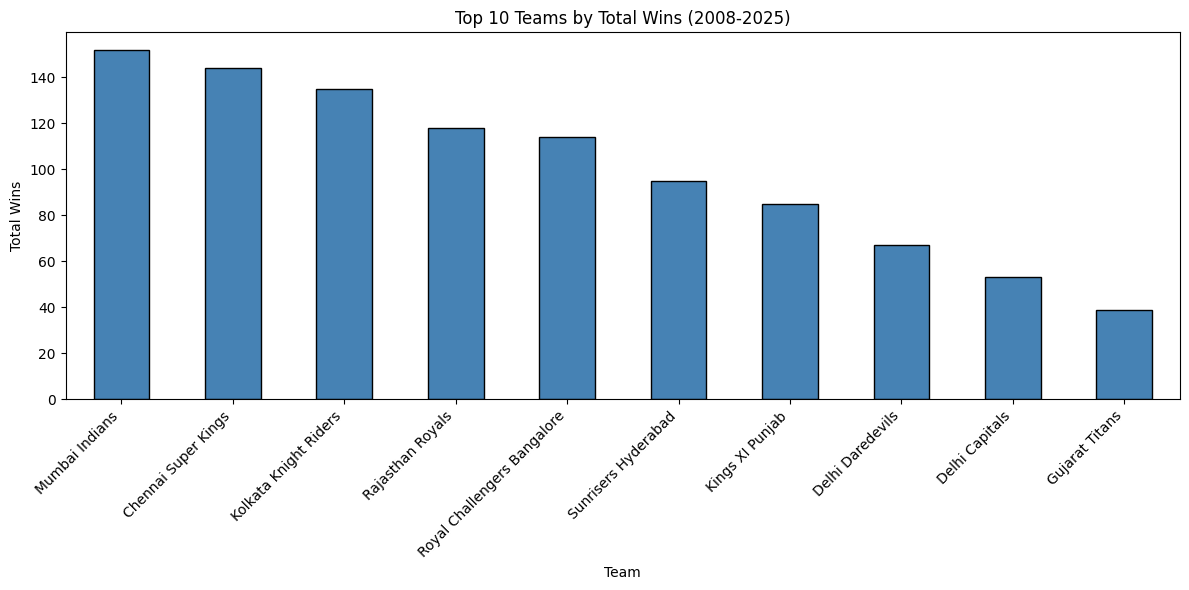

In [45]:
#top 10 teams by wins (bar chart)
top_teams=matches['match_won_by'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_teams.plot(kind='bar',color='steelblue',edgecolor='black')
plt.title('Top 10 Teams by Total Wins (2008-2025)')
plt.xlabel('Team')
plt.ylabel('Total Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("top_teams_wins.png")
plt.show()

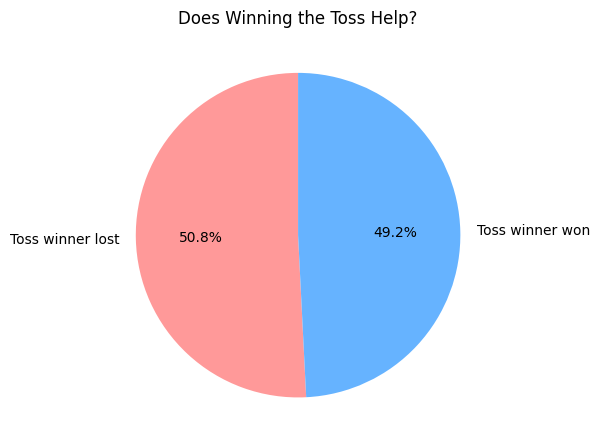

In [46]:
#toss impact on match outcome
matches['toss_won_match'] = matches['toss_winner'] == matches['match_won_by']

toss_impact = matches['toss_won_match'].value_counts()
toss_impact.index = ['Toss winner lost', 'Toss winner won']

plt.figure(figsize=(6, 6))
plt.pie(toss_impact, labels=toss_impact.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Does Winning the Toss Help?')
plt.tight_layout()
plt.savefig('toss_impact.png')
plt.show()

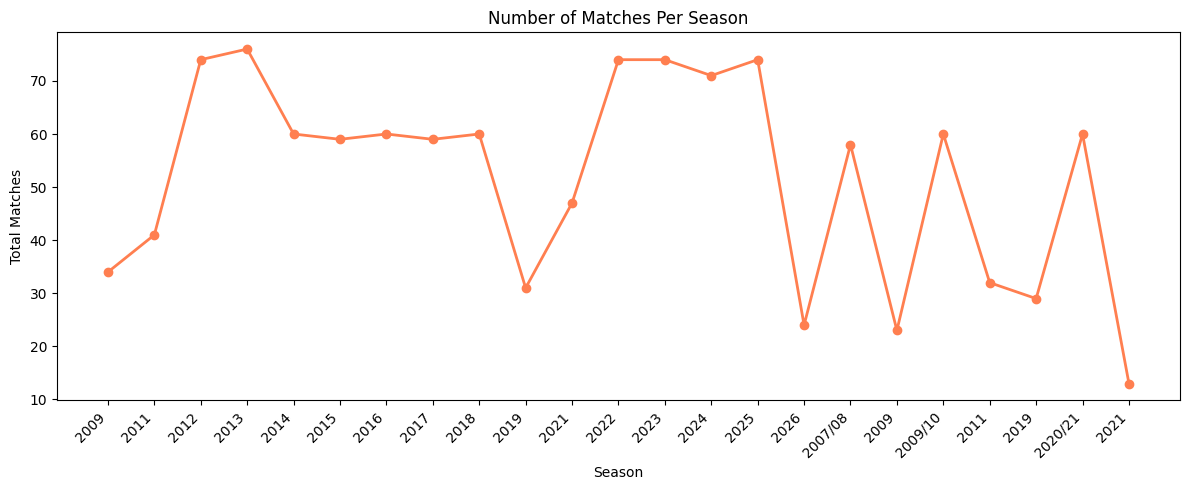

In [47]:
#matches per season (line chart)
season_counts = matches.groupby('season')['match_id'].count().reset_index()
season_counts.columns = ['season', 'total_matches']

plt.figure(figsize=(12, 5))
plt.plot(range(len(season_counts)), season_counts['total_matches'],
         marker='o', color='coral', linewidth=2)
plt.title('Number of Matches Per Season')
plt.xlabel('Season')
plt.ylabel('Total Matches')
plt.xticks(range(len(season_counts)), season_counts['season'], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('matches_per_season.png')
plt.show()

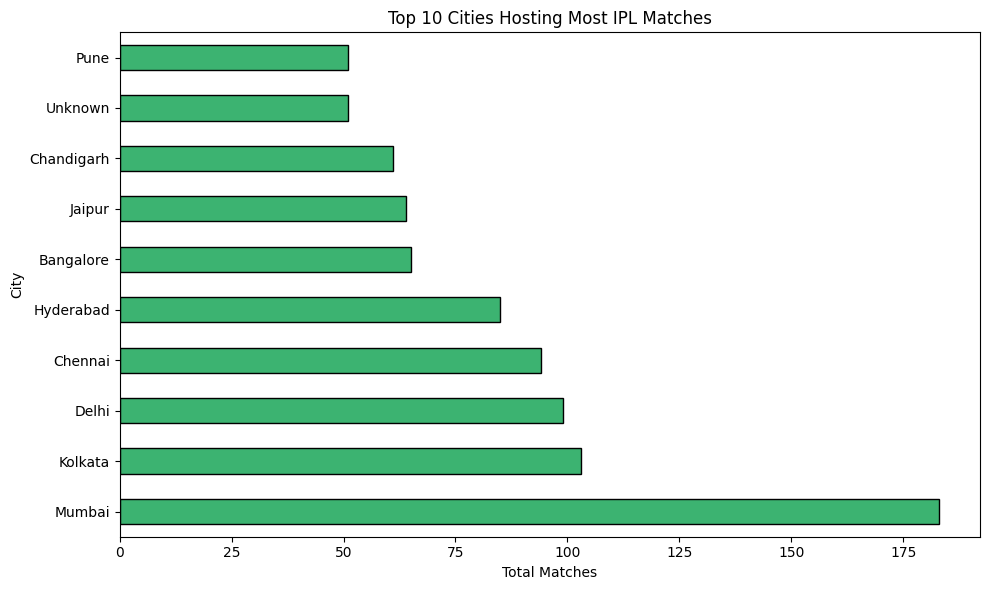

In [48]:
# top 10 cities by matches hosted (horizontal bar)
top_cities = matches['city'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_cities.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Top 10 Cities Hosting Most IPL Matches')
plt.xlabel('Total Matches')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('top_cities.png')
plt.show()

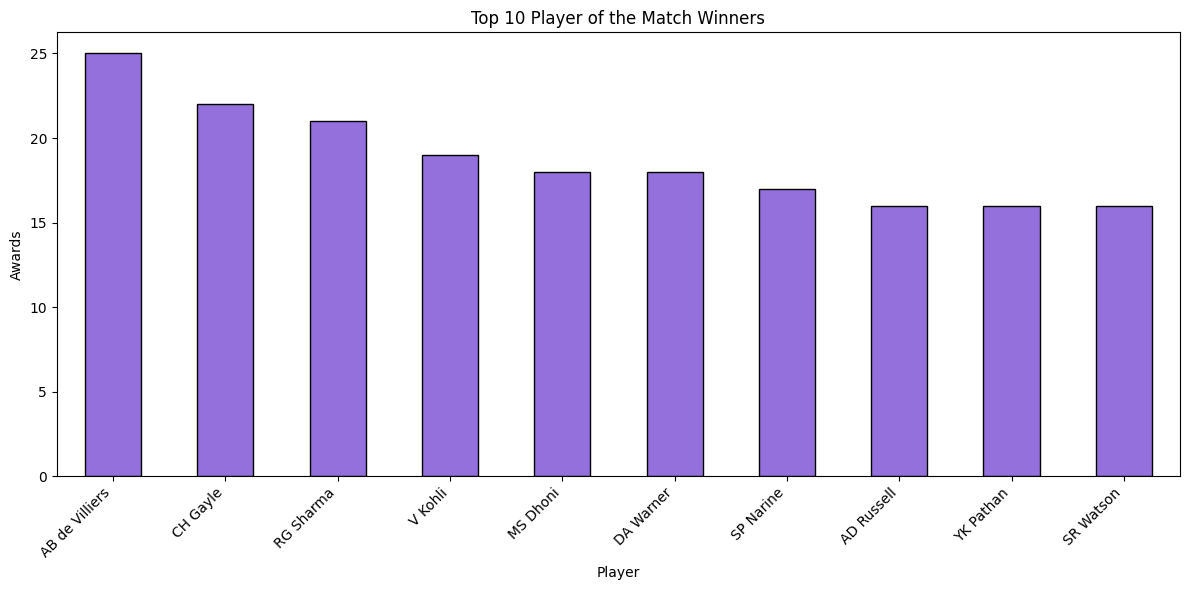

In [49]:
#top 10 Player of the Match winners
top_players = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_players.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Top 10 Player of the Match Winners')
plt.xlabel('Player')
plt.ylabel('Awards')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_players.png')
plt.show()

# IPL Match Performance Analysis (2008–2025)

**Tools used:** Python (pandas, matplotlib), SQL (SQLite), Excel  
**Dataset:** 1000+ IPL matches across 17 seasons  
**Goal:** Extract meaningful insights about team performance, toss impact, venues and players

## 1. Which team has won the most IPL matches?
Analysing total wins across all seasons to find the most dominant teams.

## 2. Does winning the toss actually help?
A common belief in cricket is that winning the toss gives a big advantage.
Let's check if the data supports this.

## 3. How has IPL grown over the seasons?
Tracking the number of matches played each season shows how the tournament has expanded over time.

## 4. Which cities host the most IPL matches?
Certain cities dominate as IPL venues — let's find out which ones.

## 5. Who are the most impactful players?
Player of the Match awards are a direct measure of individual match-winning performances.

## Key Findings

1. **MI and CSK dominate** — Mumbai Indians and Chennai Super Kings have the highest win counts across all seasons, making them the most consistent teams in IPL history.

2. **Toss impact is overrated** — Winning the toss results in a match win only ~50% of the time, meaning toss advantage is largely a myth statistically.

3. **IPL has grown significantly** — The number of matches per season has increased from around 60 in 2008 to 74+ in recent seasons, reflecting the tournament's expansion.

4. **Mumbai is the IPL capital** — Mumbai hosts the most matches of any city, followed by Kolkata and Delhi.

5. **AB de Villiers and CH Gayle lead Player of the Match awards** — These two players stand out as the most match-winning individuals across the tournament's history.